In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('../../data/processed/tweets_clean.csv')
print('Data loaded:', df.shape)
print(df.head(5))

Data loaded: (12679, 10)
             tweet_id airline_sentiment negativereason         airline  \
0  570301083672813571           neutral            NaN  Virgin America   
1  570301031407624196          negative     Bad Flight  Virgin America   
2  570300817074462722          negative     Can't Tell  Virgin America   
3  570300767074181121          negative     Can't Tell  Virgin America   
4  570300616901320704          positive            NaN  Virgin America   

         name  retweet_count  \
0  yvonnalynn              0   
1    jnardino              0   
2    jnardino              0   
3    jnardino              0   
4  cjmcginnis              0   

                                                text  \
0  @VirginAmerica I didn't today... Must mean I n...   
1  @VirginAmerica it's really aggressive to blast...   
2  @VirginAmerica and it's a really big bad thing...   
3  @VirginAmerica seriously would pay $30 a fligh...   
4  @VirginAmerica yes, nearly every time I fly VX...   



# Exploratory Data Analysis (EDA)

## Chart 1 — Sentiment by Airline
Analysing sentiment breakdown across all 6 airlines 
to identify which airline has the worst customer perception.

In [4]:
df.groupby(['airline', 'airline_sentiment']).size().unstack()

airline_sentiment,negative,neutral,positive
airline,,,
American,1854,338,252
Delta,852,519,422
Southwest,1103,497,450
US Airways,2147,296,204
United,2452,496,373
Virgin America,167,133,124


You have this table stored from your groupby. Now you need to convert each row to percentages.
For each airline, divide each sentiment count by the total tweets for that airline, then multiply by 100.

In [9]:
airline_sentiment = df.groupby(['airline', 'airline_sentiment']).size().unstack()
airline_pct = airline_sentiment.div(airline_sentiment.sum(axis=1), axis=0) * 100
print(airline_pct.round(1))

airline_sentiment  negative  neutral  positive
airline                                       
American               75.9     13.8      10.3
Delta                  47.5     28.9      23.5
Southwest              53.8     24.2      22.0
US Airways             81.1     11.2       7.7
United                 73.8     14.9      11.2
Virgin America         39.4     31.4      29.2


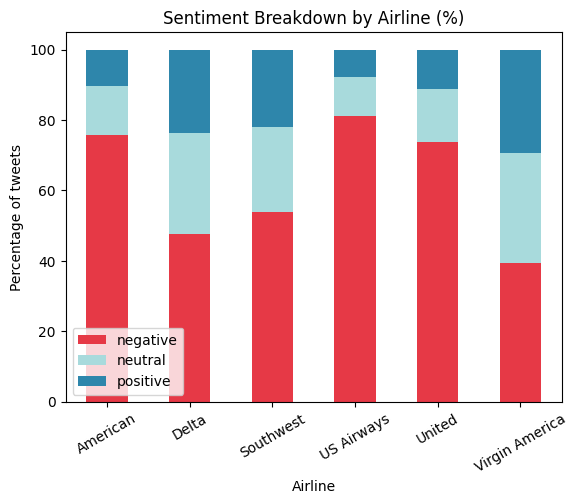

In [12]:
COLORS = {'negative':'#E63946', 'neutral':'#A8DADC', 'positive':'#2E86AB'}

airline_pct[['negative','neutral','positive']].plot(
    kind='bar', stacked=True,
    color=[COLORS['negative'], COLORS['neutral'], COLORS['positive']])
plt.title('Sentiment Breakdown by Airline (%)')
plt.xlabel('Airline')
plt.ylabel('Percentage of tweets')
plt.legend()
plt.xticks(rotation =30)
plt.savefig('../../outputs/01_sentiment_by_airline.png',dpi=150, bbox_inches='tight')
plt.show()

## Key Findings — Sentiment by Airline

- US Airways has the worst sentiment at 81.1% negative
- Virgin America has the best sentiment at 39.4% negative
- Legacy carriers (US Airways, United, American) perform worse 
  than newer airlines (Virgin America, Delta)
- Southwest and Delta show similar sentiment patterns

Chart 2 — Tweet Volume By Airline


Analysing Tweet Volume By Airlines.

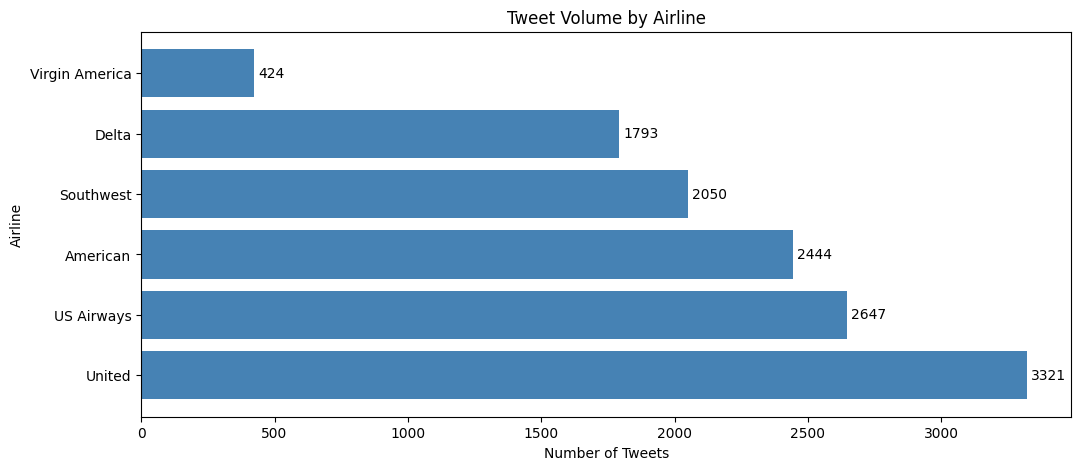

In [16]:
vol = df['airline'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bar=plt.barh(vol.index, vol.values, color='steelblue')
plt.title('Tweet Volume by Airline')
plt.xlabel('Number of Tweets')
plt.ylabel('Airline')
ax.bar_label(bar, padding=3)
plt.savefig('../../outputs/02_tweet_volume_by_airline.png', 
            dpi=150, bbox_inches='tight')
plt.show()

High volume + High negativity = 
Large number of unhappy customers publicly complaining
= serious brand reputation damage
= potential customer churn at scale

Chart 3 — Top 10 Reasons for Negative Tweets


Analysing Reasons for Tweets.

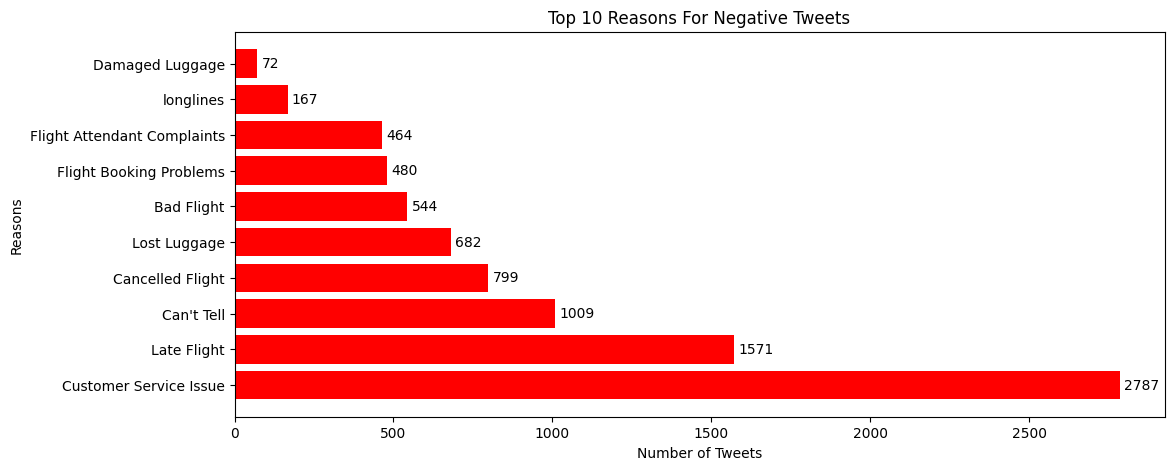

In [21]:
neg_df = df[df['airline_sentiment'] == 'negative']
negative_df = neg_df['negativereason'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 5))
bar=plt.barh(negative_df.index, negative_df.values, color='red')
plt.title('Top 10 Reasons For Negative Tweets')
plt.xlabel('Number of Tweets')
plt.ylabel('Reasons')
ax.bar_label(bar, padding=3)
plt.savefig('../../outputs/03_negativity_reasons.png', dpi=150, bbox_inches='tight')
plt.show()